# ONLINE LEARNING APPLICATIONS - Course Project

## Riccardo Piantoni

### A.Y. 2025/2026

In [29]:
%load_ext autoreload
%autoreload 2

import numpy as np

import matplotlib.pyplot as plt

#from advertising_market_simulator import AdvertisementMarketSimulator
from environment.environment import Environment
from campaigns.slightly_non_stationary_campaign import SlightlyNonStationaryCampaign
from bidders.UCB_based.sliding_window_combinatorial_ucb_like_bidder import SlidingWindowCombinatorialUCBLikeBidder
from bidders.UCB_based.cusum_combinatorial_ucb_like_bidder import CUSUMCombinatorialUCBLikeBidder
from bidders.primal_dual.primal_dual_bidder import PrimalDualBidder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Requirement 4: Slightly non-stationary environments with multiple campaigns

### Non-stationary environment

Build a slightly non-stationary environment for the pricing problem. At a high level:
- Rounds are partitioned in intervals
- In each interval the distribution of highest competing bids is fixed
- Each interval has a different distribution

Modeling assumptions: A slight non-stationarity can come from the bids intrinsically changing due to a number of reasons, i.e. because budgets get depleted or reset by the competitors, or for individual adaptation of the competitors' learning algorithms. Also, the correlation between campaigns is slightly non-stationary too. For example: during holidays of events such as Black Friday, people are likely to spend more, so it is more important to secure a slot for your own product (practically, because of higher q, I guess).

In [30]:
N_TRIALS = 2  # trials for proper curve estimation

BIDS_SPACE = np.linspace(0.0, 1.0, 11)  # possible bids = action space of size 10

# market = AdvertisementMarketSimulator()
environment = Environment(BIDS_SPACE)
environment.generate_random_campaigns(n_campaigns=3, campaign_type=SlightlyNonStationaryCampaign, min_competitors=3, max_competitors=5, conflicts_percentage=0.4, seed=47)  # generate a single campaign with random qualities for each advertisers
print(environment)

N_USERS = 10000  # number of ads to be shown sequentially = n_rounds = T

RHO = 1  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)

-- ENVIRONMENT: --
Bids space: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Number of campaigns: 3
Campaigns:
    -- CAMPAIGN: --
    Type: Slightly Non-Stationary
    Description: Competing bids sampled from a slightly non-stationary distribution, which is partitioned in stationary phases.
    Ad qualities: [1. 1. 1. 1. 1. 1.]
    Number of advertisers: 6
    Number of competitors: 5
    Number of phases: 5
    -- CAMPAIGN: --
    Type: Slightly Non-Stationary
    Description: Competing bids sampled from a slightly non-stationary distribution, which is partitioned in stationary phases.
    Ad qualities: [1. 1. 1. 1.]
    Number of advertisers: 4
    Number of competitors: 3
    Number of phases: 2
    -- CAMPAIGN: --
    Type: Slightly Non-Stationary
    Description: Competing bids sampled from a slightly non-stationary distribution, which is partitioned in stationary phases.
    Ad qualities: [1. 1. 1. 1.]
    Number of advertisers: 4
    Number of competitors: 3
    Number of phase

### Algorithm

Extend the Combinatorial-UCB approach in Requirement 2 with:
- sliding window
- a change detector

### Compare

Compare the performance of:
- Combinatorial-UCB with sliding window
- Combinatorial-UCB with the change detector
- The primal-dual method

In [31]:
M = 50              # number of samples to be collected in estimation phase of an arm to initialize CUSUM (not too many, or estimation is going to take too long!)
EPS = 0.05          # how much we expect a single reward to deviate from the mean, this acts like a "dampening" factor that prevents estimated std building up from too quickly, limits the rate of "false positives"
                    # this also signals the minimum change in mean that we consider significant in practice, since a change of 0.0000001 would not really be relevant...
                    # TODO: I think relating this to the spacing between bids might actually be a good idea)
H = 2               # cumulate estimated std that signals a change in behavior, this too limits the rate of "false positives" -> larger = fewer "false alarms", but slower detection
ALPHA = 0.05        # exploration probability
 
def run_trials_combinatorial_clairvoyant(n_trials, n_users, starting_budget, my_valuation, environment: Environment):
    """RHO = rho  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)
    STARTING_BUDGET = starting_budget #RHO * N_USERS     # or np.inf for no budget

    MY_VALUATION = my_valuation  # my true valuation of the ads (assumed to be known)"""

    all_regrets = []
    all_payments = []
    all_pulls = []

    for trial in range(n_trials):
        bidder = CUSUMCombinatorialUCBLikeBidder(B=starting_budget, T=n_users, valuations=[my_valuation for _ in range(environment.N_CAMPAIGNS)], environment=environment,
                                                 M=M, eps=EPS, h=H, alpha=ALPHA)  # create a UCB-like bidder with the specified budget, number of rounds, valuation, and valid bids

        utilities, my_bids, my_payments, total_wins = environment.simulate_environment(bidder, n_users=n_users, seed=10+trial*637) # seed=47   


        #gamma = []
        expected_clairvoyant_utility = []
        #expected_clairvoyant_payment = []
    
        # for i in range(environment.N_CAMPAIGNS):
        #     # NOTE: in the multiple campaigns version, this is no longer only the gamma, but also the marginals 
        gamma_i, marginals_i, expected_clairvoyant_utility, expected_clairvoyant_payment_i = environment.compute_clairvoyant_strategy_combinatorial_simple(bidder, campaign_indices=None)
        #     #gamma.append(gamma_i)
        #     expected_clairvoyant_utility.append(expected_clairvoyant_utility_i)
        #     #expected_clairvoyant_payment.append(expected_clairvoyant_payment_i)
        print(gamma_i)
        print(marginals_i)
        print(expected_clairvoyant_utility)
        print(expected_clairvoyant_payment_i)
    
        #gamma = np.array(gamma)                                                     # shape: (N_CAMPAIGNS)
        expected_clairvoyant_utility = np.array(expected_clairvoyant_utility)       # shape: (N_CAMPAIGNS)
        #expected_clairvoyant_payment = np.array(expected_clairvoyant_payment)       # shape: (N_CAMPAIGNS)


        cumulative_payments = np.cumsum(my_payments, axis=0)
        cumulative_regrets = np.cumsum(expected_clairvoyant_utility - utilities.sum(axis=1), axis=0)    # shape: (1,) - (n_users, 1) = (n_users, 1)  # cumulative regret for each campaign

        all_regrets.append(cumulative_regrets)
        all_payments.append(cumulative_payments)
        all_pulls.append(bidder.get_total_pulls_per_arm())

    all_regrets = np.array(all_regrets)         # shape: (n_trials, n_users, N_CAMPAIGNS)
    all_payments = np.array(all_payments)       # shape: (n_trials, n_users, N_CAMPAIGNS)
    all_pulls = np.array(all_pulls)             # shape: (n_trials, N_CAMPAIGNS, len(BIDS_SPACE))  # number of times each bid was pulled for each campaign
    print(all_regrets.shape, all_payments.shape, all_pulls.shape)

    avg_regrets = all_regrets.mean(axis=0)
    std_regrets = all_regrets.std(axis=0)

    avg_payments = all_payments.mean(axis=0)
    std_payments = all_payments.std(axis=0)

    avg_pulls = all_pulls.mean(axis=0)
    std_pulls = all_pulls.std(axis=0)


    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    # --------------------------------------------------
    # 1. Cumulative payments
    # --------------------------------------------------
    axes[0].plot(cumulative_payments)
    axes[0].set_xlabel('$t$')
    axes[0].set_ylabel('$\\sum c_t$')
    axes[0].axhline(starting_budget, color='red', label='Budget')
    axes[0].legend()
    axes[0].set_title('Cumulative Payments of UCB-Like Approach (No Budget Constraint)')

    # --------------------------------------------------
    # 2. Cumulative regret
    # --------------------------------------------------
    axes[1].plot(cumulative_regrets)
    axes[1].set_xlabel('$t$')
    axes[1].set_ylabel('$\\sum R_t$')
    axes[1].set_title('Cumulative Regret of UCB-Like Approach (No Budget Constraint)')

    # Hide the unused 6th subplot
    axes[2].axis('off')

    # --------------------------------------------------
    # 3. Chosen bids
    # --------------------------------------------------
    for i in range(bidder.N_CAMPAIGNS):
        axes[3].plot(bidder.bids, avg_pulls[i])
        axes[3].fill_between(
            bidder.bids,
            avg_pulls[i] - std_pulls[i],
            avg_pulls[i] + std_pulls[i],
            alpha=0.3
        )

    axes[3].set_xlabel('$b$')
    axes[3].set_ylabel('$n(b)$')
    axes[3].set_title('Chosen Bids of UCB-Like Approach (No Budget Constraint)')

    # --------------------------------------------------
    # 4. Cumulative payments by campaign
    # --------------------------------------------------
    for i in range(bidder.N_CAMPAIGNS):
        axes[4].plot(np.arange(n_users), avg_payments[:, i])
        axes[4].fill_between(
            np.arange(n_users),
            avg_payments[:, i] - std_payments[:, i],
            avg_payments[:, i] + std_payments[:, i],
            alpha=0.3
        )

    axes[4].set_xlabel('$t$')
    axes[4].set_ylabel('$\\sum c_t$')
    axes[4].axhline(starting_budget, color='red', label='Budget')
    axes[4].legend()
    axes[4].set_title('Cumulative Payments of UCB-Like Approach (No Budget Constraint)')

    # --------------------------------------------------
    # 5. Cumulative regret by campaign
    # --------------------------------------------------
    # for i in range(bidder.N_CAMPAIGNS):
    axes[5].plot(np.arange(n_users), avg_regrets)
    axes[5].fill_between(
        np.arange(n_users),
        avg_regrets - std_regrets,
        avg_regrets + std_regrets,
        alpha=0.3
    )

    axes[5].set_xlabel('$t$')
    axes[5].set_ylabel('$\\sum R_t$')
    axes[5].set_title('Cumulative Regret of UCB-Like Approach (No Budget Constraint)')

    plt.tight_layout()
    plt.show()

Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([   0,  192,  937, 2293, 9355]), array([   0, 7255]), array([   0, 1652, 2763, 6265, 9408])]
joined_phase_change_times: [   0  192  937 1652 2293 2763 6265 7255 9355 9408]
joined_indices: [array([0, 1, 2, 2, 3, 3, 3, 3, 4, 4], dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1], dtype=int64), array([0, 0, 0, 1, 1, 2, 3, 3, 3, 4], dtype=int64)]
campaign_gamma_values: [array([[ 0.,  0.,  0.,  0.,  0., -0.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1., -0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -0.,  1.,  0.],
       [ 0.,  0.,  0.,  0., -0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -0.,  1.,  0.]]), array([[ 0.,  0.,  0.,  0., -0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  1., -0.,  0.,  0.]]), array([[ 0.,  0.,  0.,  0., -0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.],
       [ 0.,  0.,  1., -0.,  0.,  0.,  0.,  0.],
       [ 0.,  1., -0.,  0.,  0.,  0.,  0.

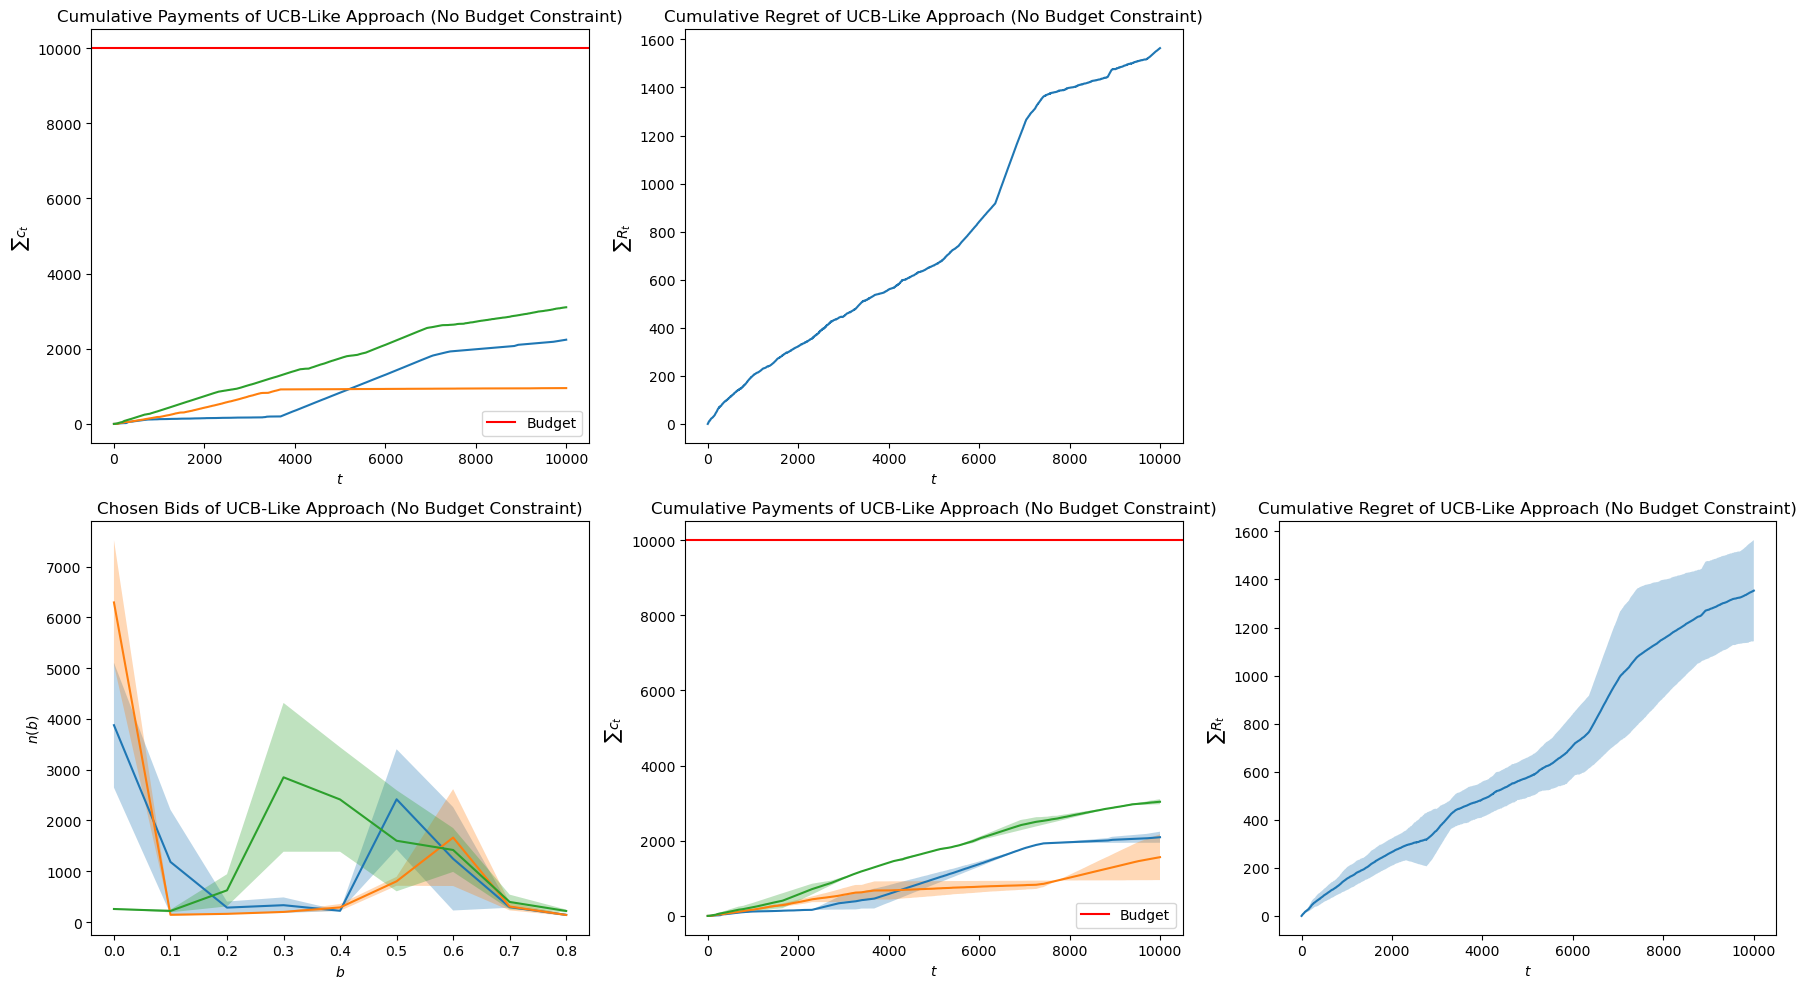

In [32]:
STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

MY_VALUATION = 0.8  # my true valuation of the ads (assumed to be known)

run_trials_combinatorial_clairvoyant(n_trials=N_TRIALS, n_users=N_USERS, starting_budget=STARTING_BUDGET, my_valuation=MY_VALUATION, environment=environment)

In [37]:
WINDOW_SIZE = np.sqrt(N_USERS)  # window size for the sliding window UCB-like bidder = T log T / T

def run_trials_combinatorial_clairvoyant(n_trials, n_users, starting_budget, my_valuation, environment: Environment):
    """RHO = rho  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)
    STARTING_BUDGET = starting_budget #RHO * N_USERS     # or np.inf for no budget

    MY_VALUATION = my_valuation  # my true valuation of the ads (assumed to be known)"""

    all_regrets = []
    all_payments = []
    all_pulls = []

    for trial in range(n_trials):
        bidder = SlidingWindowCombinatorialUCBLikeBidder(B=starting_budget, T=n_users, valuations=[my_valuation for _ in range(environment.N_CAMPAIGNS)], environment=environment,
                                                         window_size=WINDOW_SIZE)  # create a UCB-like bidder with the specified budget, number of rounds, valuation, and valid bids

        utilities, my_bids, my_payments, total_wins = environment.simulate_environment(bidder, n_users=n_users, seed=10+trial) # seed=47   


        #gamma = []
        expected_clairvoyant_utility = []
        #expected_clairvoyant_payment = []
    
        # for i in range(environment.N_CAMPAIGNS):
        #     # NOTE: in the multiple campaigns version, this is no longer only the gamma, but also the marginals 
        gamma_i, marginals_i, expected_clairvoyant_utility, expected_clairvoyant_payment_i = environment.compute_clairvoyant_strategy_combinatorial_simple(bidder, campaign_indices=None)
        #     #gamma.append(gamma_i)
        #     expected_clairvoyant_utility.append(expected_clairvoyant_utility_i)
        #     #expected_clairvoyant_payment.append(expected_clairvoyant_payment_i)
        print(gamma_i)
        print(marginals_i)
        print(expected_clairvoyant_utility)
        print(expected_clairvoyant_payment_i)
    
        #gamma = np.array(gamma)                                                     # shape: (N_CAMPAIGNS)
        expected_clairvoyant_utility = np.array(expected_clairvoyant_utility)       # shape: (N_CAMPAIGNS)
        #expected_clairvoyant_payment = np.array(expected_clairvoyant_payment)       # shape: (N_CAMPAIGNS)


        cumulative_payments = np.cumsum(my_payments, axis=0)
        cumulative_regrets = np.cumsum(expected_clairvoyant_utility - utilities.sum(axis=1), axis=0)    # shape: (1,) - (n_users, 1) = (n_users, 1)  # cumulative regret for each campaign

        all_regrets.append(cumulative_regrets)
        all_payments.append(cumulative_payments)
        all_pulls.append(bidder.get_total_pulls_per_arm())

    all_regrets = np.array(all_regrets)         # shape: (n_trials, n_users, N_CAMPAIGNS)
    all_payments = np.array(all_payments)       # shape: (n_trials, n_users, N_CAMPAIGNS)
    all_pulls = np.array(all_pulls)             # shape: (n_trials, N_CAMPAIGNS, len(BIDS_SPACE))  # number of times each bid was pulled for each campaign
    print(all_regrets.shape, all_payments.shape, all_pulls.shape)

    avg_regrets = all_regrets.mean(axis=0)
    std_regrets = all_regrets.std(axis=0)

    avg_payments = all_payments.mean(axis=0)
    std_payments = all_payments.std(axis=0)

    avg_pulls = all_pulls.mean(axis=0)
    std_pulls = all_pulls.std(axis=0)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    # --------------------------------------------------
    # 1. Cumulative payments
    # --------------------------------------------------
    axes[0].plot(cumulative_payments)
    axes[0].set_xlabel('$t$')
    axes[0].set_ylabel('$\\sum c_t$')
    axes[0].axhline(starting_budget, color='red', label='Budget')
    axes[0].legend()
    axes[0].set_title('Cumulative Payments of UCB-Like Approach (No Budget Constraint)')

    # --------------------------------------------------
    # 2. Cumulative regret
    # --------------------------------------------------
    axes[1].plot(cumulative_regrets)
    axes[1].set_xlabel('$t$')
    axes[1].set_ylabel('$\\sum R_t$')
    axes[1].set_title('Cumulative Regret of UCB-Like Approach (No Budget Constraint)')

    # Hide the unused 6th subplot
    axes[2].axis('off')

    # --------------------------------------------------
    # 3. Chosen bids
    # --------------------------------------------------
    for i in range(bidder.N_CAMPAIGNS):
        axes[3].plot(bidder.bids, avg_pulls[i])
        axes[3].fill_between(
            bidder.bids,
            avg_pulls[i] - std_pulls[i],
            avg_pulls[i] + std_pulls[i],
            alpha=0.3
        )

    axes[3].set_xlabel('$b$')
    axes[3].set_ylabel('$n(b)$')
    axes[3].set_title('Chosen Bids of UCB-Like Approach (No Budget Constraint)')

    # --------------------------------------------------
    # 4. Cumulative payments by campaign
    # --------------------------------------------------
    for i in range(bidder.N_CAMPAIGNS):
        axes[4].plot(np.arange(n_users), avg_payments[:, i])
        axes[4].fill_between(
            np.arange(n_users),
            avg_payments[:, i] - std_payments[:, i],
            avg_payments[:, i] + std_payments[:, i],
            alpha=0.3
        )

    axes[4].set_xlabel('$t$')
    axes[4].set_ylabel('$\\sum c_t$')
    axes[4].axhline(starting_budget, color='red', label='Budget')
    axes[4].legend()
    axes[4].set_title('Cumulative Payments of UCB-Like Approach (No Budget Constraint)')

    # --------------------------------------------------
    # 5. Cumulative regret by campaign
    # --------------------------------------------------
    # for i in range(bidder.N_CAMPAIGNS):
    axes[5].plot(np.arange(n_users), avg_regrets)
    axes[5].fill_between(
        np.arange(n_users),
        avg_regrets - std_regrets,
        avg_regrets + std_regrets,
        alpha=0.3
    )

    axes[5].set_xlabel('$t$')
    axes[5].set_ylabel('$\\sum R_t$')
    axes[5].set_title('Cumulative Regret of UCB-Like Approach (No Budget Constraint)')

    plt.tight_layout()
    plt.show()

c:\Users\richy\Desktop\Polimi\Didattica\A.A. 2025-2026\Online Learning Applications\online-learning-applications-project-2025-2026\bidders\UCB_based\sliding_window_combinatorial_ucb_like_bidder.py:34: RuntimeWarning: Mean of empty slice
  avg_f = np.nanmean(self.f_cache, axis=0)
c:\Users\richy\Desktop\Polimi\Didattica\A.A. 2025-2026\Online Learning Applications\online-learning-applications-project-2025-2026\bidders\UCB_based\sliding_window_combinatorial_ucb_like_bidder.py:35: RuntimeWarning: Mean of empty slice
  avg_c = np.nanmean(self.c_cache, axis=0)


Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([   0,  192,  937, 2293, 9355]), array([   0, 7255]), array([   0, 1652, 2763, 6265, 9408])]
joined_phase_change_times: [   0  192  937 1652 2293 2763 6265 7255 9355 9408]
joined_indices: [array([0, 1, 2, 2, 3, 3, 3, 3, 4, 4], dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1], dtype=int64), array([0, 0, 0, 1, 1, 2, 3, 3, 3, 4], dtype=int64)]
campaign_gamma_values: [array([[ 0.,  0.,  0.,  0.,  0., -0.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1., -0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -0.,  1.,  0.],
       [ 0.,  0.,  0.,  0., -0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -0.,  1.,  0.]]), array([[ 0.,  0.,  0.,  0., -0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  1., -0.,  0.,  0.]]), array([[ 0.,  0.,  0.,  0., -0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.],
       [ 0.,  0.,  1., -0.,  0.,  0.,  0.,  0.],
       [ 0.,  1., -0.,  0.,  0.,  0.,  0.

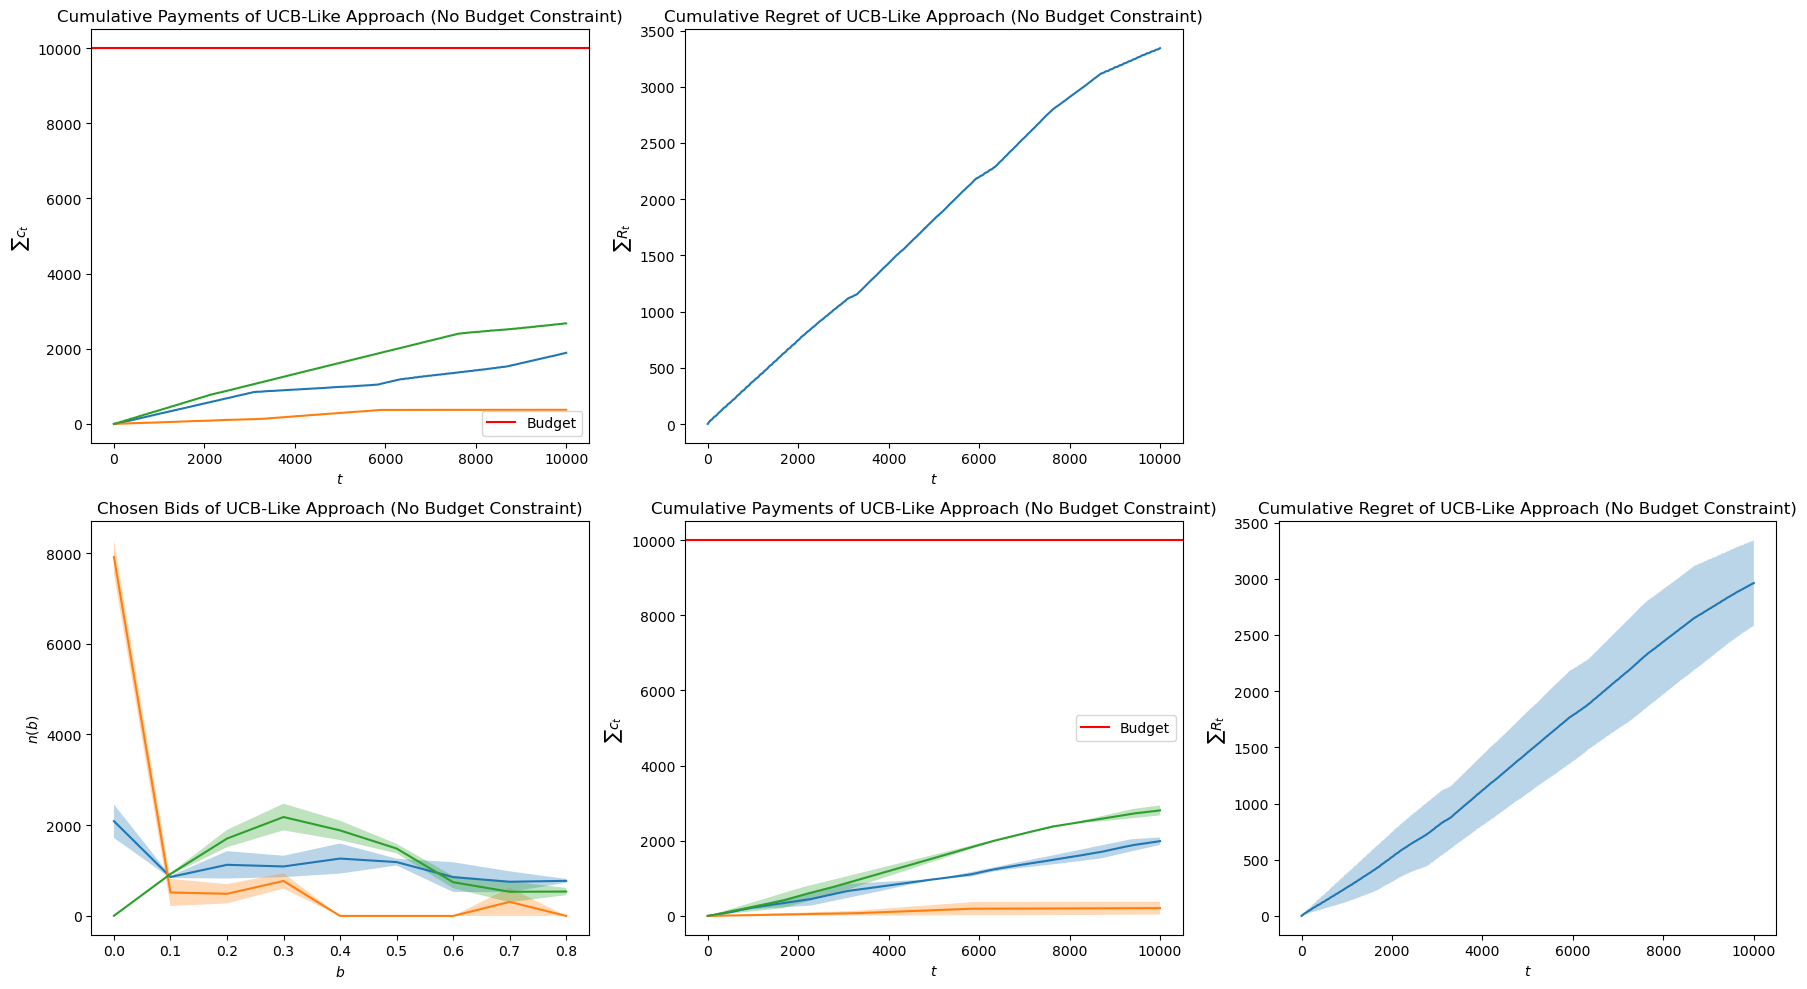

In [38]:
STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

MY_VALUATION = 0.8  # my true valuation of the ads (assumed to be known)

run_trials_combinatorial_clairvoyant(n_trials=N_TRIALS, n_users=N_USERS, starting_budget=STARTING_BUDGET, my_valuation=MY_VALUATION, environment=environment)

In [35]:
LEARNING_RATE_PRIMAL = 1
LEARNING_RATE_DUAL = 1

# TODO: generalize this new structure with the clairvoyant computed after and for each trial (because the competing bids change from trial to trial)
# so that you don't have to change it everywhere, also separate the computations from the plots and put everything into the environment and pass the bidder class 
# as a function parameter and also return whatever is needed for the plots, or maybe create an ad-hoc class that stores everything so that you can access it later as needed?
# The error is in simple_clairvoyant though, I should move the bid generation somewhere better, probably not in the initialization of an instance, but I am going to lose the 
# bids and the data! Maybe I should regenerate the whole Environment each time and store the trials separately? Probably not...
def run_trials_combinatorial_clairvoyant(n_trials, n_users, starting_budget, my_valuation, environment: Environment):
    """RHO = rho  # budget per round -> define either rho or the starting budget B and derive the other (rho = B/T)
    STARTING_BUDGET = starting_budget #RHO * N_USERS     # or np.inf for no budget

    MY_VALUATION = my_valuation  # my true valuation of the ads (assumed to be known)"""

    all_regrets = []
    all_payments = []
    all_pulls = []

    for trial in range(n_trials):
        bidder = PrimalDualBidder(B=starting_budget, T=n_users, valuations=[my_valuation for _ in range(environment.N_CAMPAIGNS)], environment=environment,
                                  learning_rate_primal=LEARNING_RATE_PRIMAL, learning_rate_dual=LEARNING_RATE_DUAL)  # create a UCB-like bidder with the specified budget, number of rounds, valuation, and valid bids

        utilities, my_bids, my_payments, total_wins = environment.simulate_environment(bidder, n_users=n_users, seed=10+trial) # seed=47   


        #gamma = []
        expected_clairvoyant_utility = []
        #expected_clairvoyant_payment = []
    
        # for i in range(environment.N_CAMPAIGNS):
        #     # NOTE: in the multiple campaigns version, this is no longer only the gamma, but also the marginals 
        gamma_i, marginals_i, expected_clairvoyant_utility, expected_clairvoyant_payment_i = environment.compute_clairvoyant_strategy_combinatorial_simple(bidder, campaign_indices=None)
        #     #gamma.append(gamma_i)
        #     expected_clairvoyant_utility.append(expected_clairvoyant_utility_i)
        #     #expected_clairvoyant_payment.append(expected_clairvoyant_payment_i)
        print(gamma_i)
        print(marginals_i)
        print(expected_clairvoyant_utility)
        print(expected_clairvoyant_payment_i)
    
        #gamma = np.array(gamma)                                                     # shape: (N_CAMPAIGNS)
        expected_clairvoyant_utility = np.array(expected_clairvoyant_utility)       # shape: (N_CAMPAIGNS)
        #expected_clairvoyant_payment = np.array(expected_clairvoyant_payment)       # shape: (N_CAMPAIGNS)


        print("Bid weights:", bidder.regret_minimizer.bid_weights)
        print("Superarm weights:", bidder.regret_minimizer.superarm_weights)


        cumulative_payments = np.cumsum(my_payments, axis=0)
        cumulative_regrets = np.cumsum(expected_clairvoyant_utility - utilities.sum(axis=1), axis=0)    # shape: (1,) - (n_users, 1) = (n_users, 1)  # cumulative regret for each campaign

        all_regrets.append(cumulative_regrets)
        all_payments.append(cumulative_payments)
        all_pulls.append(bidder.get_total_pulls_per_arm())

    all_regrets = np.array(all_regrets)         # shape: (n_trials, n_users, N_CAMPAIGNS)
    all_payments = np.array(all_payments)       # shape: (n_trials, n_users, N_CAMPAIGNS)
    all_pulls = np.array(all_pulls)             # shape: (n_trials, N_CAMPAIGNS, len(BIDS_SPACE))  # number of times each bid was pulled for each campaign
    print(all_regrets.shape, all_payments.shape, all_pulls.shape)

    avg_regrets = all_regrets.mean(axis=0)
    std_regrets = all_regrets.std(axis=0)

    avg_payments = all_payments.mean(axis=0)
    std_payments = all_payments.std(axis=0)

    avg_pulls = all_pulls.mean(axis=0)
    std_pulls = all_pulls.std(axis=0)


    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    # --------------------------------------------------
    # 1. Cumulative payments
    # --------------------------------------------------
    axes[0].plot(cumulative_payments)
    axes[0].set_xlabel('$t$')
    axes[0].set_ylabel('$\\sum c_t$')
    axes[0].axhline(starting_budget, color='red', label='Budget')
    axes[0].legend()
    axes[0].set_title('Cumulative Payments of UCB-Like Approach (No Budget Constraint)')

    # --------------------------------------------------
    # 2. Cumulative regret
    # --------------------------------------------------
    axes[1].plot(cumulative_regrets)
    axes[1].set_xlabel('$t$')
    axes[1].set_ylabel('$\\sum R_t$')
    axes[1].set_title('Cumulative Regret of UCB-Like Approach (No Budget Constraint)')

    # Hide the unused 6th subplot
    axes[2].axis('off')

    # --------------------------------------------------
    # 3. Chosen bids
    # --------------------------------------------------
    for i in range(bidder.N_CAMPAIGNS):
        axes[3].plot(bidder.bids, avg_pulls[i])
        axes[3].fill_between(
            bidder.bids,
            avg_pulls[i] - std_pulls[i],
            avg_pulls[i] + std_pulls[i],
            alpha=0.3
        )

    axes[3].set_xlabel('$b$')
    axes[3].set_ylabel('$n(b)$')
    axes[3].set_title('Chosen Bids of UCB-Like Approach (No Budget Constraint)')

    # --------------------------------------------------
    # 4. Cumulative payments by campaign
    # --------------------------------------------------
    for i in range(bidder.N_CAMPAIGNS):
        axes[4].plot(np.arange(n_users), avg_payments[:, i])
        axes[4].fill_between(
            np.arange(n_users),
            avg_payments[:, i] - std_payments[:, i],
            avg_payments[:, i] + std_payments[:, i],
            alpha=0.3
        )

    axes[4].set_xlabel('$t$')
    axes[4].set_ylabel('$\\sum c_t$')
    axes[4].axhline(starting_budget, color='red', label='Budget')
    axes[4].legend()
    axes[4].set_title('Cumulative Payments of UCB-Like Approach (No Budget Constraint)')

    # --------------------------------------------------
    # 5. Cumulative regret by campaign
    # --------------------------------------------------
    # for i in range(auxiliary_bidder.N_CAMPAIGNS):
    axes[5].plot(np.arange(n_users), avg_regrets)
    axes[5].fill_between(
        np.arange(n_users),
        avg_regrets - std_regrets,
        avg_regrets + std_regrets,
        alpha=0.3
    )

    axes[5].set_xlabel('$t$')
    axes[5].set_ylabel('$\\sum R_t$')
    axes[5].set_title('Cumulative Regret of UCB-Like Approach (No Budget Constraint)')

    plt.tight_layout()
    plt.show()

Clairvoyant - combinatorial over campaigns - simple version
campaign_phase_change_times: [array([   0,  192,  937, 2293, 9355]), array([   0, 7255]), array([   0, 1652, 2763, 6265, 9408])]
joined_phase_change_times: [   0  192  937 1652 2293 2763 6265 7255 9355 9408]
joined_indices: [array([0, 1, 2, 2, 3, 3, 3, 3, 4, 4], dtype=int64), array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1], dtype=int64), array([0, 0, 0, 1, 1, 2, 3, 3, 3, 4], dtype=int64)]
campaign_gamma_values: [array([[ 0.,  0.,  0.,  0.,  0., -0.,  1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1., -0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -0.,  1.,  0.],
       [ 0.,  0.,  0.,  0., -0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -0.,  1.,  0.]]), array([[ 0.,  0.,  0.,  0., -0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  1., -0.,  0.,  0.]]), array([[ 0.,  0.,  0.,  0., -0.,  1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.],
       [ 0.,  0.,  1., -0.,  0.,  0.,  0.,  0.],
       [ 0.,  1., -0.,  0.,  0.,  0.,  0.

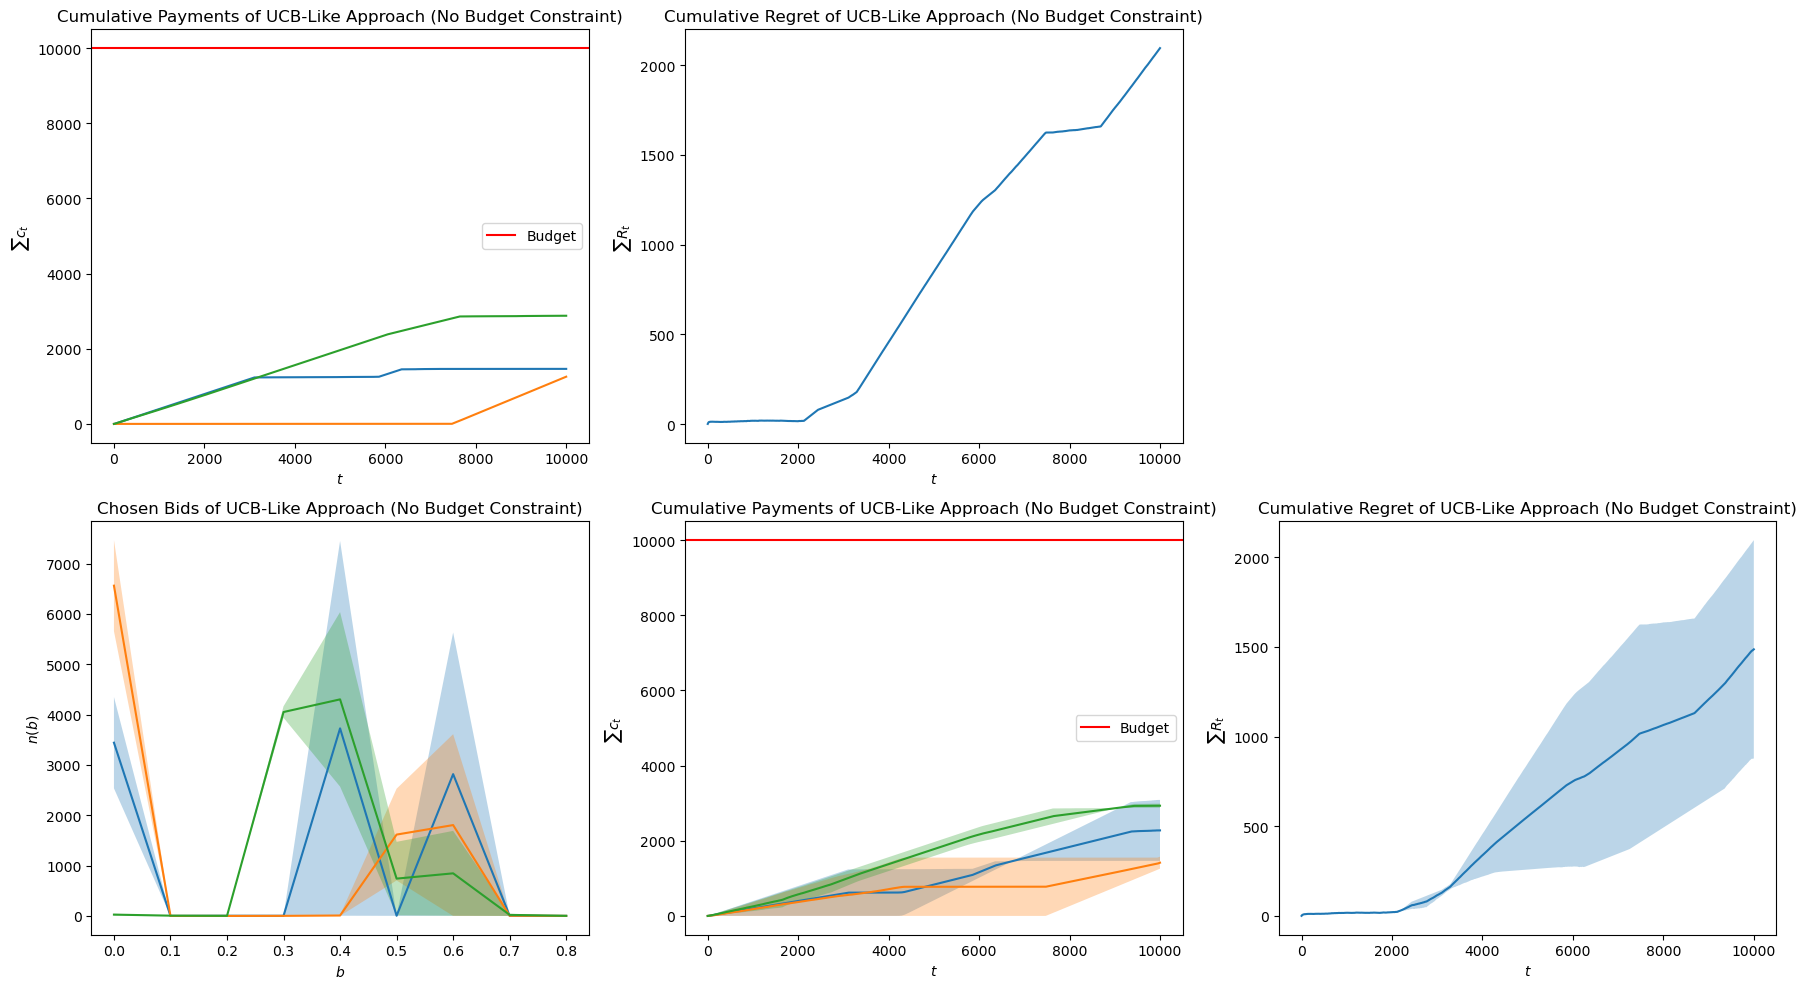

In [36]:
STARTING_BUDGET = RHO * N_USERS     # or np.inf for no budget

MY_VALUATION = 0.8  # my true valuation of the ads (assumed to be known)

run_trials_combinatorial_clairvoyant(n_trials=N_TRIALS, n_users=N_USERS, starting_budget=STARTING_BUDGET, my_valuation=MY_VALUATION, environment=environment)